# VI Methods Benchmark: Speed, Accuracy, and Compilation

Comprehensive comparison of all variational inference methods in diffsed.
For each method we measure:
- **Compile time** (one-time JIT/XLA cost)
- **Run time** (per-galaxy execution after compilation)
- **Hamiltonian** H at convergence (lower = better fit)
- **Chi2/dof** (should be ~1 for a good fit)
- **Posterior predictive** (predicted data should bracket observed)

In [1]:
import logging
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
logging.getLogger("nifty8").setLevel(logging.ERROR)

from diffsed import Fitter, Model, ParamSpec, Uniform
from diffsed.models.observation.filters import load_filter_set
from diffsed.models.sps.dsps_wrapper import load_ssp_data

## Setup: Mock Galaxy with Known Truth

We generate a synthetic galaxy with known physical properties so we can check
whether each method recovers the truth. The mock uses:
- **Truncated skew-normal SFH** (tsnorm) with 8 free parameters
- **SDSS ugriz** photometry at z=0.1
- **SNR=20** per band (realistic ground-based photometry)

This is a smooth (parametric) SFH — no stochastic GP field. Dimensionality D=8
is low enough for NUTS to work, giving us a gold-standard comparison.

In [2]:
ssp = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

spec = ParamSpec(
    mean_sfh_type="tsnorm",
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.2, 5.0),
    sfh_tsnorm_skew=Uniform(-1.0, 1.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-1.5, 0.2),
    dust_tau_bc=Uniform(0.0, 3.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=-0.7,
    redshift=0.1,
)

model = Model(spec, ssp, filters=filters)
key = jax.random.PRNGKey(42)
true_params = spec.sample(key)
mock = model.mock(true_params, snr=20.0, key=key)
fitter = Fitter(model, mock.flux_obs, mock.noise, data_type="photometry")

D = len(spec.free_params)
N = len(mock.flux_obs)
print(f"D = {D} free parameters, N = {N} data points")

W0320 22:10:16.653050 13626452 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_47645/2764002974.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp, filters=filters)


D = 8 free parameters, N = 5 data points


## Method Overview

| Method | Optimization | Posterior Draws | Backend |
|--------|-------------|-----------------|---------|
| **geovi** | geoVI (resample+update schedule) | Nonlinear geoVI-curved | NIFTy tight loop |
| fast_evi | MGVI warmup → geoVI | Linear CG (MGVI) | NIFTy tight loop |
| fast_mgvi | MGVI (linear only) | Linear CG (MGVI) | NIFTy tight loop |
| nifty_geovi | Full `jft.optimize_kl` | Nonlinear geoVI-curved | NIFTy full pipeline |
| geovi_nuts | geoVI optimization | BlackJAX NUTS | NIFTy + BlackJAX |
| nuts | — | BlackJAX NUTS from MAP | BlackJAX |
| native_geovi | geoVI (resample+update, JIT) | Nonlinear geoVI-curved (JIT) | Pure JAX `lax.while_loop` |
| map | Adam gradient descent | — (point estimate) | JAX optax |

### Key concepts

- **Nonlinear posterior draws** (geoVI-curved): Samples follow the posterior's
  banana-shaped degeneracies. Essential for accurate uncertainty estimates.
- **Linear posterior draws** (MGVI): Gaussian approximation. Fast but misses
  non-Gaussian structure. Chi2/dof will be worse.
- **Resample+update schedule**: Fresh geoVI samples at iterations 0, 5, 10...
  deterministic refinement (nonlinear_update) in between. Prevents both
  oscillation (from fresh samples) and staleness (from fixed samples).
- **Native JIT**: Entire optimization loop compiled to a single XLA program.
  Microsecond per-galaxy execution after one-time compilation.

## Benchmark All Methods

For each method we run twice:
1. **Cold run** — includes any JIT/XLA compilation overhead
2. **Warm run** — pure execution time (cached compilation)

The difference is the one-time compilation cost.

In [3]:
N_ITER = 15
N_SAMP = 3
N_POST = 200

methods = {
    # --- Default: geoVI with optimal resample+update schedule ---
    "geovi": {"method": "geovi"},
    # --- VI methods with linear posterior draws ---
    "fast_evi": {"method": "fast_evi"},
    "fast_mgvi": {"method": "fast_mgvi"},
    # --- Full NIFTy (with logging/diagnostics) ---
    "nifty_geovi": {"method": "nifty_geovi"},
    # --- Hybrid: geoVI optimization + NUTS posterior ---
    "geovi_nuts": {"method": "geovi_nuts"},
    # --- Pure MCMC (gold standard for low D) ---
    "nuts": {"method": "nuts"},
    # --- Native JIT (same behavior as geovi, compiled to XLA) ---
    "native_geovi": {"method": "native_geovi", "n_seeds": 1},
    # --- Point estimate ---
    "map": {"method": "map", "n_steps": 500},
}

results = {}
timings = {}

for label, kwargs in methods.items():
    method = kwargs.pop("method")
    common = {}
    if method == "nuts":
        # NUTS has its own kwargs: n_warmup, n_samples (not n_iterations)
        common = {"n_warmup": 200, "n_samples": N_POST}
    elif method != "map":
        common = {
            "n_iterations": N_ITER,
            "n_samples": N_SAMP,
            "n_posterior_samples": N_POST,
        }

    # Run twice: first = cold (may include compilation), second = warm (cached)
    try:
        t0 = time.time()
        r = fitter.run(method, verbose=False, key=jax.random.PRNGKey(42), **common, **kwargs)
        t_cold = time.time() - t0

        t0 = time.time()
        r = fitter.run(method, verbose=False, key=jax.random.PRNGKey(42), **common, **kwargs)
        t_warm = time.time() - t0
    except Exception as e:
        print(f"{label:30s}  FAILED: {e}")
        kwargs["method"] = method
        continue

    t_compile = max(0, t_cold - t_warm)

    # Compute chi2/dof
    chi2_dof = None
    try:
        if hasattr(r, "params") and isinstance(r.params, dict) and r.params:
            pred = model.predict_photometry(r.params)
            chi2 = float(jnp.sum(((mock.flux_obs - pred) / mock.noise) ** 2))
            chi2_dof = chi2 / N
    except Exception:
        pass

    results[label] = r
    timings[label] = {
        "cold": t_cold,
        "warm": t_warm,
        "compile": t_compile,
        "chi2_dof": chi2_dof,
    }

    # Diagnostics
    n_post_actual = 0
    posterior_type = "none"
    if isinstance(r.samples, dict) and r.samples:
        first_key = next(iter(r.samples))
        n_post_actual = len(r.samples[first_key])
        posterior_type = (
            r.diagnostics.get("sample_mode", r.method) if hasattr(r, "diagnostics") else r.method
        )

    chi2_str = f"chi2/dof={chi2_dof:.2f}" if chi2_dof is not None else "chi2/dof=—"
    print(
        f"{label:30s}  compile={t_compile:6.1f}s  run={t_warm:6.1f}s  "
        f"total={t_cold:6.1f}s  {chi2_str}  "
        f"n_samples={n_post_actual}  posterior={posterior_type}"
    )

    # Restore kwargs for next iteration
    kwargs["method"] = method

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0320 22:10:19.156015 13626353 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0320 22:10:20.374756 13626353 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

geovi_nuts                      compile=   1.1s  run=  26.8s  total=  27.8s  chi2/dof=1.53  n_samples=206  posterior=nonlinear_resample


nuts                            compile=   0.5s  run=   5.0s  total=   5.5s  chi2/dof=0.36  n_samples=200  posterior=NUTS (BlackJAX)


W0320 22:15:19.450966 13626353 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


native_geovi                    compile=  13.5s  run=   0.7s  total=  14.2s  chi2/dof=2.13  n_samples=200  posterior=evi_jit


map                             compile=   0.0s  run=   0.2s  total=   0.2s  chi2/dof=6.27  n_samples=0  posterior=none


## Timing Comparison

**Compile time** is paid once (per model configuration + iteration count).
After that, each galaxy runs at the **cached run time**.

For NIFTy-based methods (geovi, fast_evi, nifty_geovi, geovi_nuts), the
"compile" time is mainly NIFTy's internal JIT. For native methods, it's
XLA compiling the full optimization loop into a single program.

The native JIT engine's per-galaxy time is in **milliseconds** — but the
compile cost is higher because XLA must trace nested while_loops.

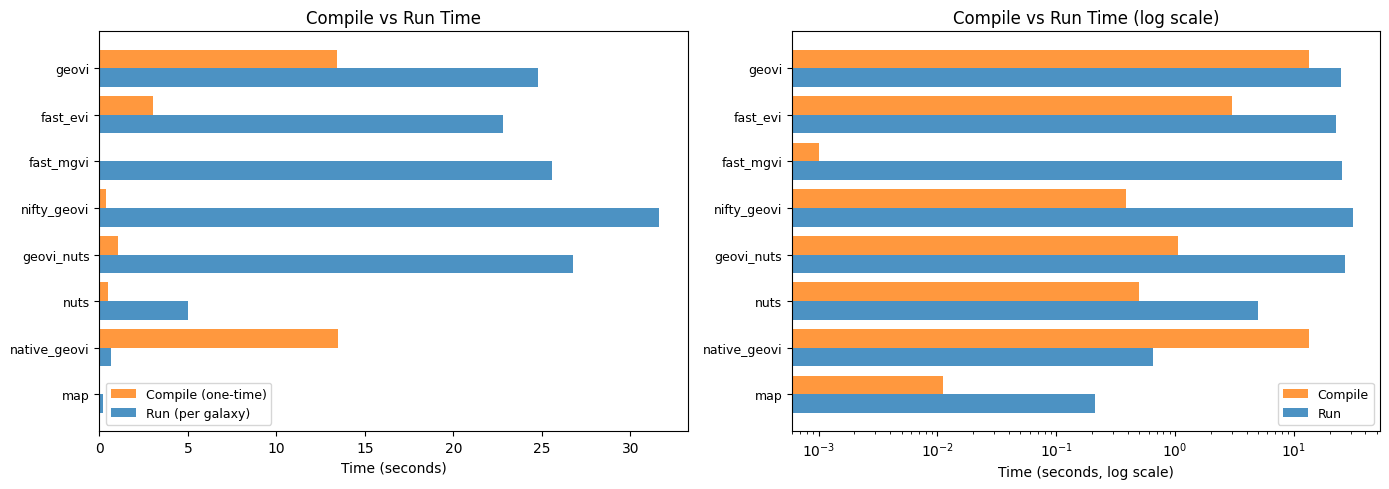

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = list(timings.keys())
compile_times = [timings[l]["compile"] for l in labels]
run_times = [timings[l]["warm"] for l in labels]

y = np.arange(len(labels))
ax1.barh(y, compile_times, height=0.4, label="Compile (one-time)", color="C1", alpha=0.8)
ax1.barh(y + 0.4, run_times, height=0.4, label="Run (per galaxy)", color="C0", alpha=0.8)
ax1.set_yticks(y + 0.2)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel("Time (seconds)")
ax1.set_title("Compile vs Run Time")
ax1.legend(fontsize=9)
ax1.invert_yaxis()

# Log scale version
ax2.barh(
    y, [max(0.001, c) for c in compile_times], height=0.4, label="Compile", color="C1", alpha=0.8
)
ax2.barh(
    y + 0.4, [max(0.001, r) for r in run_times], height=0.4, label="Run", color="C0", alpha=0.8
)
ax2.set_yticks(y + 0.2)
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlabel("Time (seconds, log scale)")
ax2.set_xscale("log")
ax2.set_title("Compile vs Run Time (log scale)")
ax2.legend(fontsize=9)
ax2.invert_yaxis()

fig.tight_layout()
plt.show()

## Accuracy Comparison: Chi2/dof

Chi2/dof measures how well the **posterior mean** fits the data:
- **Chi2/dof ≈ 1**: Good fit (residuals consistent with noise)
- **Chi2/dof < 0.5**: Overfitting or noise overestimated
- **Chi2/dof > 3**: Poor fit — model doesn't explain the data

Note: low chi2/dof doesn't guarantee correct parameters (NUTS can
get stuck in a local mode with chi2=0.3 but wrong parameters).
Always check parameter recovery alongside chi2.

**Key insight**: Methods with **nonlinear posterior draws** (geovi,
native_geovi, geovi_nuts) have lower chi2 than methods with **linear
draws** (fast_evi, fast_mgvi) because the nonlinear draws capture the
banana-shaped age-dust-metallicity degeneracy.

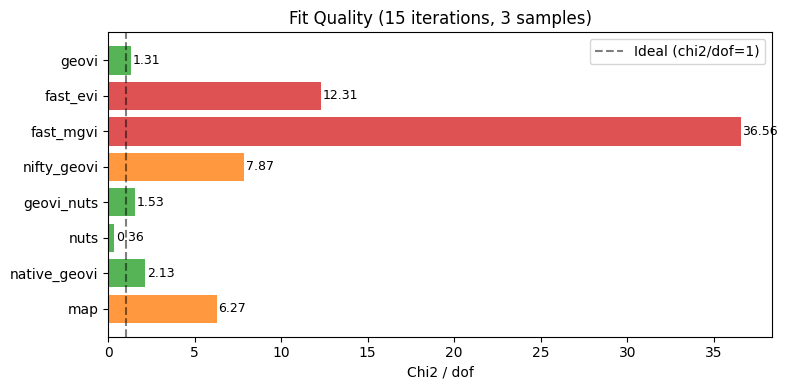

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
labels_with_chi2 = [l for l in labels if timings[l]["chi2_dof"] is not None]
chi2s = [timings[l]["chi2_dof"] for l in labels_with_chi2]
colors = ["C2" if c < 3 else "C1" if c < 10 else "C3" for c in chi2s]

bars = ax.barh(labels_with_chi2, chi2s, color=colors, alpha=0.8)
ax.axvline(1.0, color="k", ls="--", alpha=0.5, label="Ideal (chi2/dof=1)")
ax.set_xlabel("Chi2 / dof")
ax.set_title(f"Fit Quality ({N_ITER} iterations, {N_SAMP} samples)")
ax.legend()

for bar, c in zip(bars, chi2s):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{c:.2f}",
        va="center",
        fontsize=9,
    )

ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Posterior Predictive Check

For each posterior sample, we compute the predicted photometry and check
whether the observed data falls within the predicted spread (68% CI).

A good method should:
- Have the observed data points (black squares) inside the blue shaded region
- Have a shaded region that's neither too wide (uncertain) nor too narrow (overconfident)

Each panel shows one method. The title shows chi2/dof and run time.

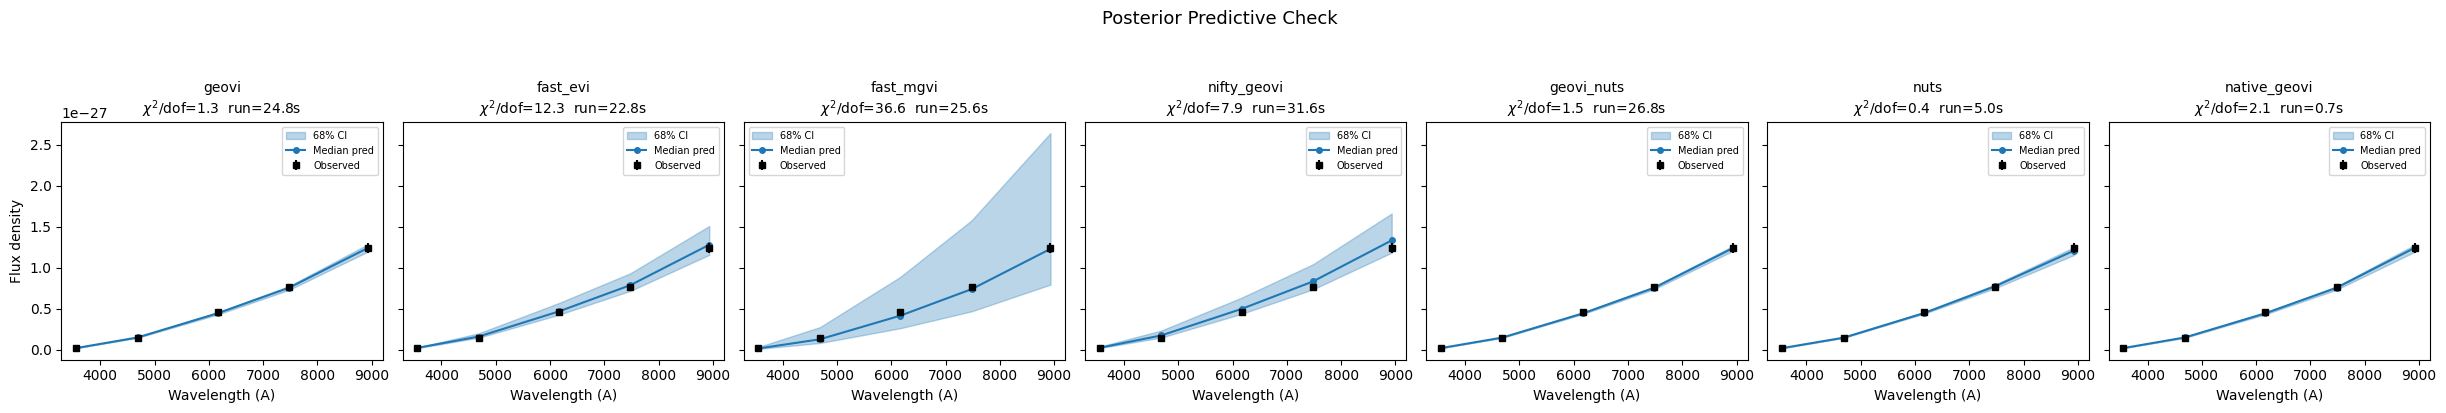

In [6]:
band_names = ["u", "g", "r", "i", "z"]
band_wave = np.array([3551, 4686, 6166, 7480, 8932])

vi_methods = [
    l for l in labels if l != "map" and isinstance(results[l].samples, dict) and results[l].samples
]
n_vi = len(vi_methods)

fig, axes = plt.subplots(1, n_vi, figsize=(3.5 * n_vi, 4), sharey=True)
if n_vi == 1:
    axes = [axes]

for ax, label in zip(axes, vi_methods):
    result = results[label]
    first_key = next(iter(result.samples))
    n_samp = min(100, len(result.samples[first_key]))

    predictions = []
    for i in range(n_samp):
        sample = {k: v[i] for k, v in result.samples.items()}
        pred = model.predict_photometry(sample)
        predictions.append(np.array(pred))

    if not predictions:
        continue

    predictions = np.stack(predictions)
    pred_med = np.median(predictions, axis=0)
    pred_lo = np.percentile(predictions, 16, axis=0)
    pred_hi = np.percentile(predictions, 84, axis=0)

    ax.fill_between(band_wave, pred_lo, pred_hi, alpha=0.3, color="C0", label="68% CI")
    ax.plot(band_wave, pred_med, "o-", color="C0", ms=4, label="Median pred")
    ax.errorbar(
        band_wave,
        np.array(mock.flux_obs),
        yerr=np.array(mock.noise),
        fmt="s",
        color="k",
        ms=5,
        label="Observed",
    )

    chi2 = timings[label]["chi2_dof"]
    chi2_str = f"$\\chi^2$/dof={chi2:.1f}" if chi2 else ""
    t_str = f"run={timings[label]['warm']:.1f}s"
    ax.set_title(f"{label}\n{chi2_str}  {t_str}", fontsize=10)
    ax.set_xlabel("Wavelength (A)")
    if ax == axes[0]:
        ax.set_ylabel("Flux density")
    ax.legend(fontsize=7)

fig.suptitle("Posterior Predictive Check", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## Parameter Recovery

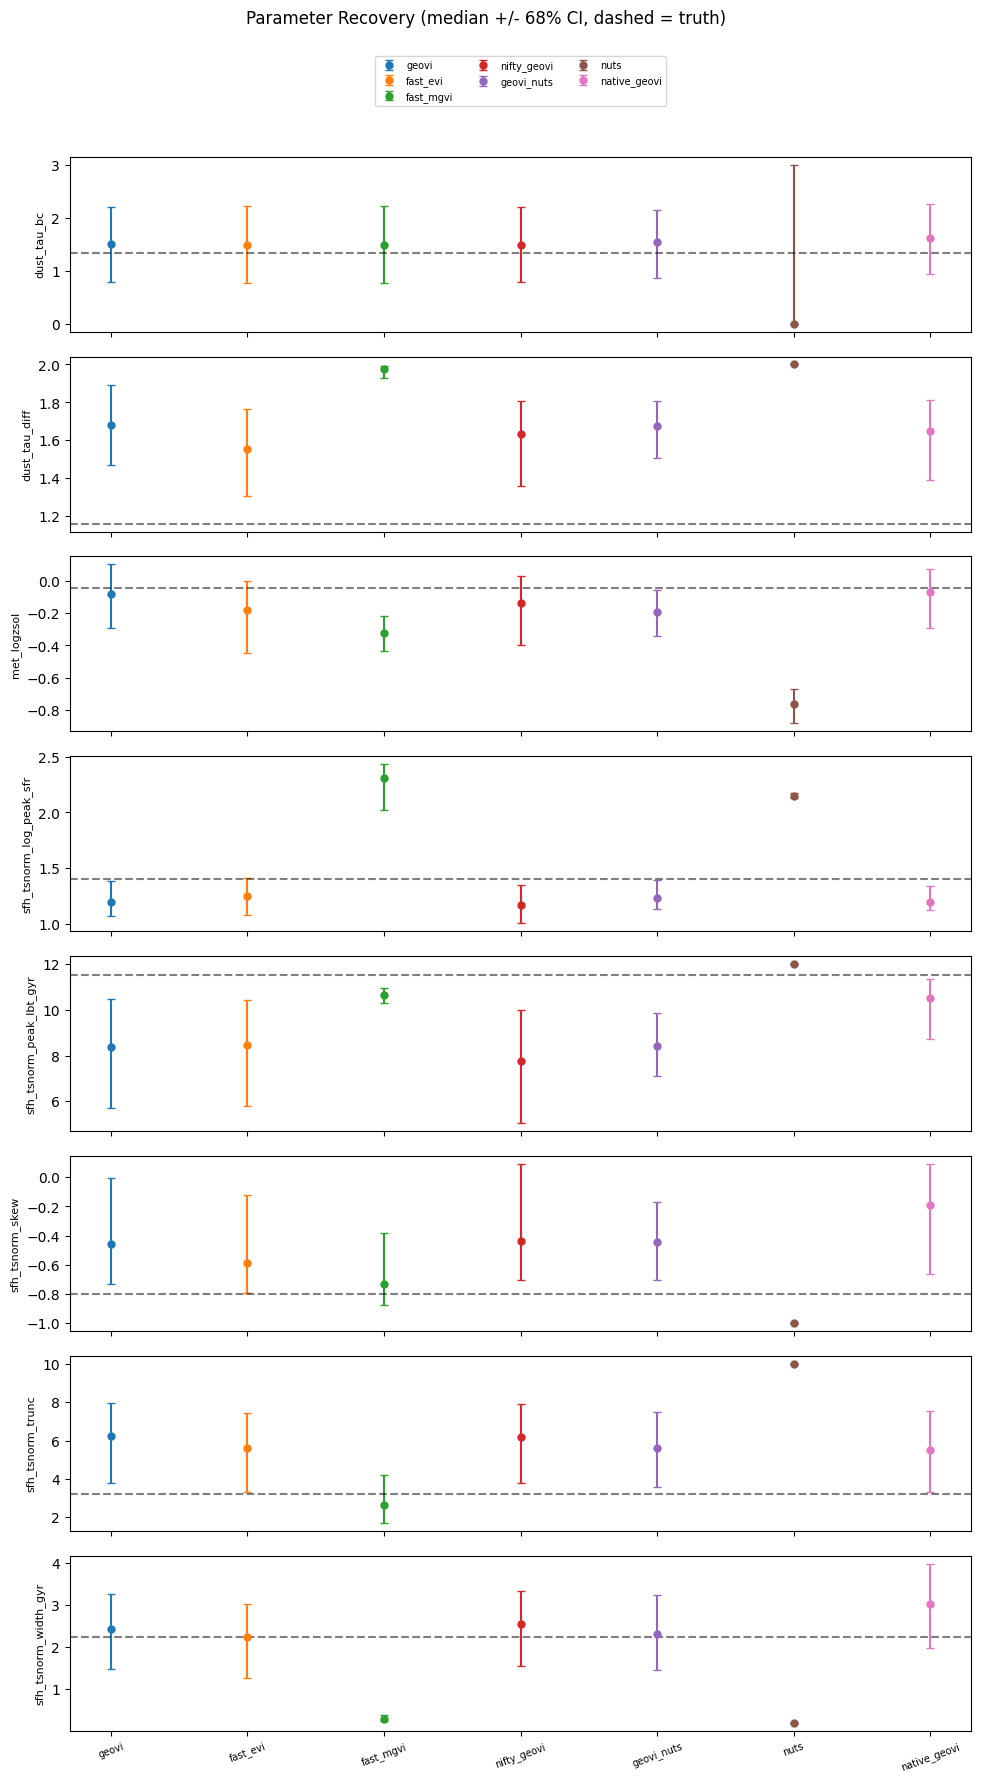

In [7]:
free_names = list(spec.free_params)
n_params = len(free_names)
vi_methods_for_params = [
    l for l in labels if l != "map" and isinstance(results[l].samples, dict) and results[l].samples
]

fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.2 * n_params), sharex=True)

for i, pname in enumerate(free_names):
    ax = axes[i]
    true_val = float(true_params[pname])

    for j, label in enumerate(vi_methods_for_params):
        result = results[label]
        if pname not in result.samples:
            continue
        vals = np.array(result.samples[pname])
        med = np.median(vals)
        lo, hi = np.percentile(vals, [16, 84])
        ax.errorbar(
            j,
            med,
            yerr=[[med - lo], [hi - med]],
            fmt="o",
            color=f"C{j}",
            ms=5,
            capsize=3,
            label=label if i == 0 else "",
        )

    ax.axhline(true_val, color="k", ls="--", alpha=0.5)
    ax.set_ylabel(pname, fontsize=8)
    ax.set_xticks(range(len(vi_methods_for_params)))
    ax.set_xticklabels(vi_methods_for_params, fontsize=7, rotation=20)

if n_params > 0:
    axes[0].legend(fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.6))

fig.suptitle("Parameter Recovery (median +/- 68% CI, dashed = truth)", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## Summary Table

In [8]:
print(f"{'Method':<30s} {'Compile':>8s} {'Run':>8s} {'Total':>8s} {'Chi2/dof':>9s}")
print("-" * 68)
for label in labels:
    t = timings[label]
    chi2 = f"{t['chi2_dof']:.2f}" if t["chi2_dof"] else "—"
    print(f"{label:<30s} {t['compile']:7.1f}s {t['warm']:7.1f}s {t['cold']:7.1f}s {chi2:>9s}")

print()
print("Notes:")
print(f"  - {N_ITER} iterations, {N_SAMP} samples/iter, {N_POST} posterior samples")
print(f"  - D = {D} free params, N = {N} data points")
print("  - 'geovi' uses optimal resample+update schedule with nonlinear posterior draws")
print("  - 'geovi_nuts' uses geoVI optimization + NUTS posterior sampling")
print("  - Compile time is one-time; run time is per-galaxy (cached)")

Method                          Compile      Run    Total  Chi2/dof
--------------------------------------------------------------------
geovi                             13.4s    24.8s    38.3s      1.31
fast_evi                           3.0s    22.8s    25.8s     12.31
fast_mgvi                          0.0s    25.6s    24.2s     36.56
nifty_geovi                        0.4s    31.6s    32.0s      7.87
geovi_nuts                         1.1s    26.8s    27.8s      1.53
nuts                               0.5s     5.0s     5.5s      0.36
native_geovi                      13.5s     0.7s    14.2s      2.13
map                                0.0s     0.2s     0.2s      6.27

Notes:
  - 15 iterations, 3 samples/iter, 200 posterior samples
  - D = 8 free params, N = 5 data points
  - 'geovi' uses optimal resample+update schedule with nonlinear posterior draws
  - 'geovi_nuts' uses geoVI optimization + NUTS posterior sampling
  - Compile time is one-time; run time is per-galaxy (cached)


## Native JIT: Compilation vs Execution Deep Dive

The native JIT engine compiles the **entire optimization loop** into a single
XLA program. This has a one-time compilation cost, but after that each galaxy
runs in **milliseconds**.

### When does JAX recompile?

JAX caches compiled programs keyed by **static arguments**. It recompiles when:
- `n_iterations` changes (e.g., 10 → 15)
- `n_samples` changes (e.g., 3 → 6)
- `sample_mode` changes (e.g., `"linear_resample"` → `"nonlinear_update"`)
- Model structure changes (different D or N)

JAX does **NOT** recompile when:
- Different galaxy data (different `pos_flat`, different `key`)
- Different noise values (same shape)
- This is the **catalog fitting** scenario: same model, different data

### Persistent XLA cache

diffsed enables XLA's persistent cache at `/tmp/diffsed_jax_cache`.
Compiled programs survive across Python sessions. First run of a new
session may still recompile, but subsequent sessions reuse the cache.

### What takes so long to compile?

The nonlinear curving has nested `jax.lax.while_loop` (CG inside Newton-CG
inside curving inside optimization loop). XLA must lower this entire
structure to HLO (High Level Operations). The linear path skips curving,
so it compiles much faster.

In [9]:
print("=== Native JIT: Compilation vs Execution Breakdown ===")
print()

# Build a fresh engine to measure compilation
fitter._jit_sampler = None
init_pos_bench = fitter._initialize_unbounded(jax.random.PRNGKey(0))
engine_bench = fitter._build_jit_engine(init_pos_bench)
flatten_b = engine_bench["flatten"]
pos_flat_b = flatten_b(init_pos_bench)

# --- Optimization: first call (compile) vs second call (cached) ---
for mode_name, mode_str in [
    ("MGVI (linear)", "linear_resample"),
    ("geoVI (nonlinear_update)", "nonlinear_update"),
]:
    # First call = compile + run
    t0 = time.time()
    engine_bench["run_evi_geovi"](
        pos_flat_b,
        jax.random.PRNGKey(42),
        n_iterations=N_ITER,
        n_samples=N_SAMP,
        kl_rtol=0.0,
        sample_mode=mode_str,
    )
    t_first = time.time() - t0

    # Second call = cached run only
    t0 = time.time()
    engine_bench["run_evi_geovi"](
        pos_flat_b,
        jax.random.PRNGKey(42),
        n_iterations=N_ITER,
        n_samples=N_SAMP,
        kl_rtol=0.0,
        sample_mode=mode_str,
    )
    t_cached = time.time() - t0

    print(f"  {mode_name}:")
    print(f"    First call (compile + run): {t_first * 1000:10.1f} ms")
    print(f"    Cached call (run only):     {t_cached * 1000:10.1f} ms")
    print(f"    Compilation overhead:        {(t_first - t_cached) * 1000:10.1f} ms")
    print()

# --- Posterior draws: first call vs cached ---
draw_keys_bench = jax.random.split(jax.random.PRNGKey(99), N_POST)

t0 = time.time()
engine_bench["draw_samples"](pos_flat_b, draw_keys_bench)
t_first_draw = time.time() - t0

t0 = time.time()
engine_bench["draw_samples"](pos_flat_b, draw_keys_bench)
t_cached_draw = time.time() - t0

print(f"  Posterior draws ({N_POST} linear CG samples):")
print(f"    First call (compile + run): {t_first_draw * 1000:10.1f} ms")
print(f"    Cached call (run only):     {t_cached_draw * 1000:10.1f} ms")
print(f"    Compilation overhead:        {(t_first_draw - t_cached_draw) * 1000:10.1f} ms")

print()
print("  === TOTAL PER-GALAXY TIME (cached) ===")
print(
    f"    Optimization + {N_POST} posterior draws: {t_cached * 1000 + t_cached_draw * 1000:.1f} ms"
)
print()
print("  === CATALOG FITTING ESTIMATE ===")
t_compile_total = max(t_first - t_cached, 0) + max(t_first_draw - t_cached_draw, 0)
t_per_galaxy = t_cached + t_cached_draw
for n_gal in [10, 100, 1000]:
    t_total = t_compile_total + n_gal * t_per_galaxy
    print(
        f"    {n_gal:5d} galaxies: {t_compile_total:.1f}s compile + "
        f"{n_gal}×{t_per_galaxy * 1000:.1f}ms = {t_total:.1f}s total"
    )

=== Native JIT: Compilation vs Execution Breakdown ===



assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0320 22:15:25.659062 13626353 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

  MGVI (linear):
    First call (compile + run):     1811.4 ms
    Cached call (run only):            0.4 ms
    Compilation overhead:            1811.1 ms



W0320 22:15:34.758012 13626353 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  geoVI (nonlinear_update):
    First call (compile + run):     7009.0 ms
    Cached call (run only):            1.9 ms
    Compilation overhead:            7007.1 ms



  Posterior draws (200 linear CG samples):
    First call (compile + run):      334.9 ms
    Cached call (run only):            0.2 ms
    Compilation overhead:             334.7 ms

  === TOTAL PER-GALAXY TIME (cached) ===
    Optimization + 200 posterior draws: 2.1 ms

  === CATALOG FITTING ESTIMATE ===
       10 galaxies: 7.3s compile + 10×2.1ms = 7.4s total
      100 galaxies: 7.3s compile + 100×2.1ms = 7.5s total
     1000 galaxies: 7.3s compile + 1000×2.1ms = 9.4s total


W0320 22:15:36.338919 13626353 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Posterior Distributions Overlay

Overlay 1D marginal posteriors from all methods on the same axes.
This shows whether different methods agree on the posterior shape,
not just the median.

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


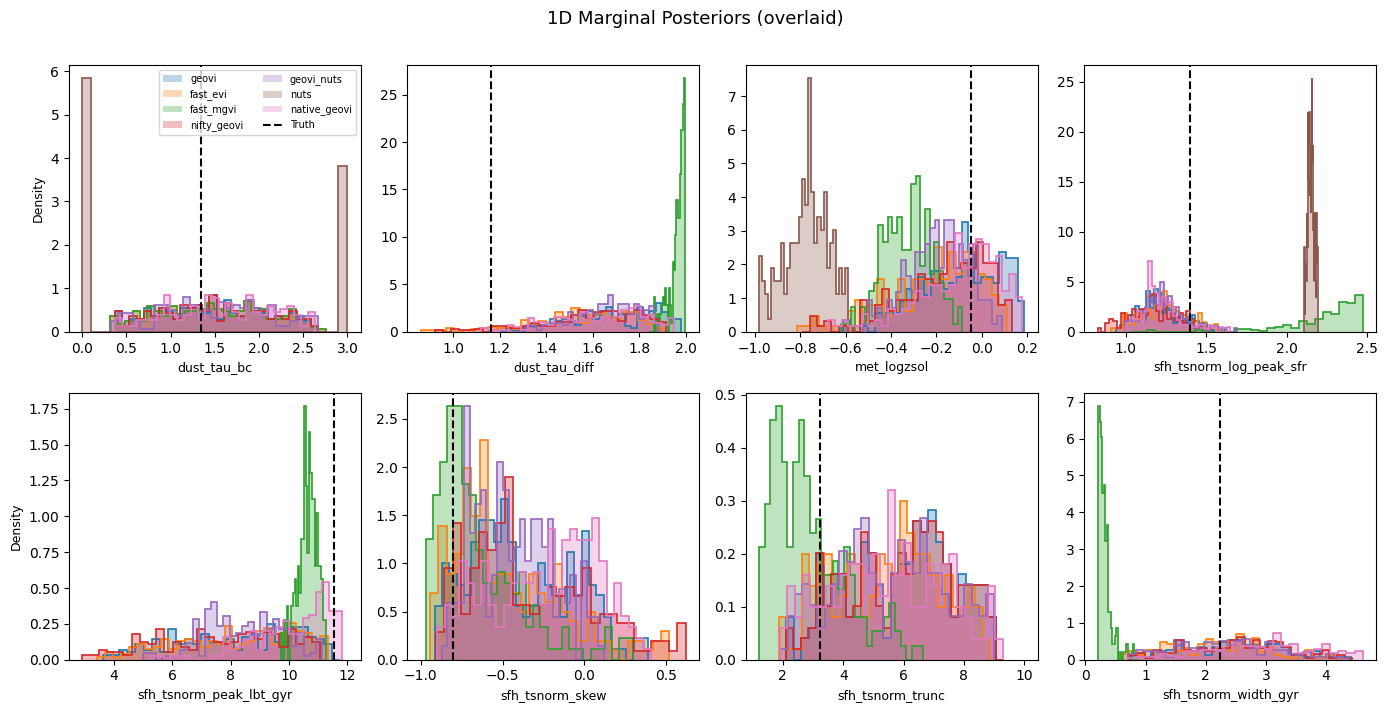

In [10]:
fig, axes = plt.subplots(2, (n_params + 1) // 2, figsize=(14, 7))
axes = axes.ravel()

colors_map = {}
for j, label in enumerate(vi_methods_for_params):
    colors_map[label] = f"C{j}"

for i, pname in enumerate(free_names):
    ax = axes[i]
    true_val = float(true_params[pname])

    for label in vi_methods_for_params:
        result = results[label]
        if pname not in result.samples:
            continue
        vals = np.array(result.samples[pname]).ravel()
        if len(vals) < 5:
            continue
        lo, hi = np.percentile(vals, [1, 99])
        bins = np.linspace(lo, hi, 30)
        ax.hist(
            vals,
            bins=bins,
            density=True,
            alpha=0.3,
            color=colors_map[label],
            label=label if i == 0 else "",
            histtype="stepfilled",
        )
        ax.hist(vals, bins=bins, density=True, color=colors_map[label], histtype="step", lw=1.2)

    ax.axvline(true_val, color="k", ls="--", lw=1.5, label="Truth" if i == 0 else "")
    ax.set_xlabel(pname, fontsize=9)
    ax.set_ylabel("Density" if i % ((n_params + 1) // 2) == 0 else "", fontsize=9)

# Remove unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=7, ncol=2, loc="upper right")
fig.suptitle("1D Marginal Posteriors (overlaid)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Posterior Predictive: All Methods Overlaid

Overlay predicted photometry from all methods on a single plot.

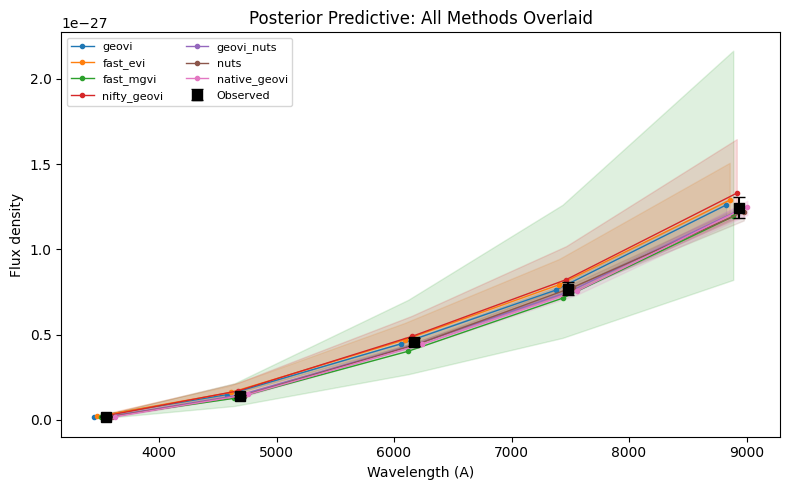

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for j, label in enumerate(vi_methods_for_params):
    result = results[label]
    first_key = next(iter(result.samples))
    n_samp = min(50, len(result.samples[first_key]))

    predictions = []
    for i_s in range(n_samp):
        sample = {k: v[i_s] for k, v in result.samples.items()}
        pred = model.predict_photometry(sample)
        predictions.append(np.array(pred))

    if not predictions:
        continue
    predictions = np.stack(predictions)
    pred_med = np.median(predictions, axis=0)
    pred_lo = np.percentile(predictions, 16, axis=0)
    pred_hi = np.percentile(predictions, 84, axis=0)

    color = colors_map[label]
    offset = (j - len(vi_methods_for_params) / 2) * 30  # slight x-offset for visibility
    ax.fill_between(
        band_wave + offset,
        pred_lo,
        pred_hi,
        alpha=0.15,
        color=color,
    )
    ax.plot(band_wave + offset, pred_med, "o-", color=color, ms=3, lw=1, label=label)

ax.errorbar(
    band_wave,
    np.array(mock.flux_obs),
    yerr=np.array(mock.noise),
    fmt="s",
    color="k",
    ms=7,
    capsize=4,
    label="Observed",
    zorder=10,
)
ax.set_xlabel("Wavelength (A)")
ax.set_ylabel("Flux density")
ax.set_title("Posterior Predictive: All Methods Overlaid")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()